<a href="https://colab.research.google.com/github/RajShreyaa/1BM23CS317_ML_LAB/blob/main/1BM23CS317_ML_Lab9_K_Means.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

First 5 rows of dataset:
   sepal_length  sepal_width  petal_length  petal_width      species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           4.7          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

Selected Features:
   petal_length  petal_width
0           1.4          0.2
1   

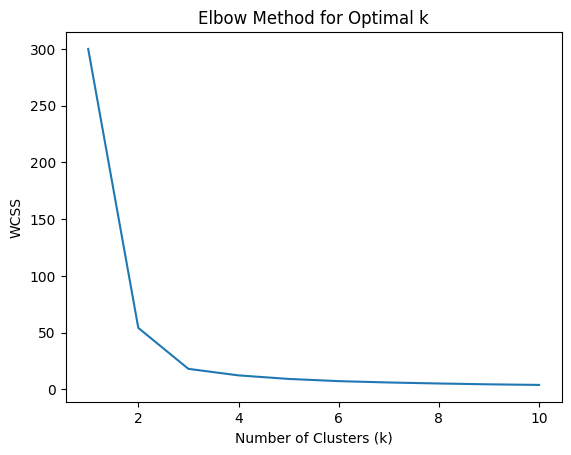


Cluster assignments:
   sepal_length  sepal_width  petal_length  petal_width      species  Cluster
0           5.1          3.5           1.4          0.2  Iris-setosa        1
1           4.9          3.0           1.4          0.2  Iris-setosa        1
2           4.7          3.2           1.3          0.2  Iris-setosa        1
3           4.6          3.1           1.5          0.2  Iris-setosa        1
4           5.0          3.6           1.4          0.2  Iris-setosa        1


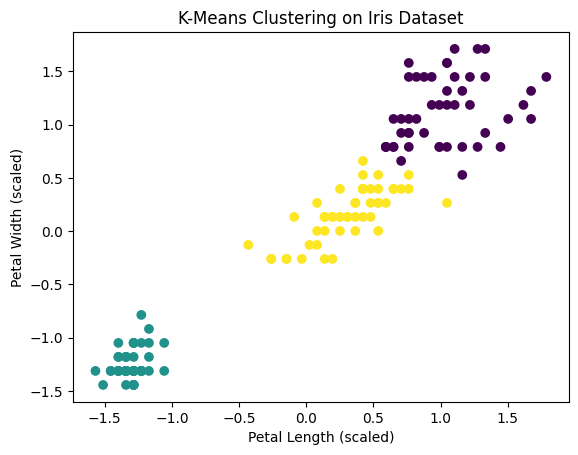

In [1]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ----------------------------------------
# Step 1: Load the dataset
# ----------------------------------------
df = pd.read_csv("iris (2).csv")

print("First 5 rows of dataset:")
print(df.head())

print("\nDataset Information:")
df.info()

# ----------------------------------------
# Step 2: Select required features
# Use only Petal Length and Petal Width
# ----------------------------------------
X = df[['petal_length', 'petal_width']]

print("\nSelected Features:")
print(X.head())

# ----------------------------------------
# Step 3: Apply Scaling
# (Important for K-Means because it uses distance)
# ----------------------------------------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------------------
# Step 4: Use Elbow Method to find optimal k
# ----------------------------------------
wcss = []  # Within Cluster Sum of Squares

for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        max_iter=300,
        n_init=10,
        random_state=42
    )

    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

# ----------------------------------------
# Step 5: Plot Elbow Graph
# ----------------------------------------
plt.figure()

plt.plot(range(1, 11), wcss)
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("WCSS")

plt.show()

# ----------------------------------------
# Step 6: Train K-Means with optimal k
# (Usually k = 3 for Iris dataset)
# ----------------------------------------
optimal_k = 3

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42
)

clusters = kmeans.fit_predict(X_scaled)

# Add cluster labels to dataset
df['Cluster'] = clusters

print("\nCluster assignments:")
print(df.head())

# ----------------------------------------
# Step 7: Visualize Clusters
# ----------------------------------------
plt.figure()

plt.scatter(
    X_scaled[:, 0],
    X_scaled[:, 1],
    c=clusters
)

plt.title("K-Means Clustering on Iris Dataset")
plt.xlabel("Petal Length (scaled)")
plt.ylabel("Petal Width (scaled)")

plt.show()